# Homework 3

Датасет: [TMDB 5000 Movie Dataset](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata), тот же собственный файл, что использовался в предыдущих работах.

Сначала строятся две регрессионные модели для прогноза `vote_average`, затем задача переводится в классификацию. Вводится класс:

- **1 — хороший фильм**, если `vote_average > 6`;
- **0 — обычный или плохой фильм**, если `vote_average <= 6`.

Строки с `vote_average = 0` исключаются: это фильмы без пользовательской оценки, а не фильмы с реальной оценкой ноль.

In [22]:
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, log_loss, mean_absolute_error, mean_squared_error,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

movies = pd.read_csv("tmdb_5000_movies.csv")
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
data = movies.loc[movies["vote_average"] > 0].copy()
data["release_year"] = data["release_date"].dt.year
data["good_movie"] = (data["vote_average"] > 6).astype(int)

# Нулевые budget/revenue/runtime означают отсутствие сведений.
for col in ["budget", "revenue", "runtime"]:
    data.loc[data[col] == 0, col] = np.nan

# Сильно скошенные денежные и счётные признаки логарифмируются.
data["log_budget"] = np.log1p(data["budget"])
data["log_revenue"] = np.log1p(data["revenue"])
data["log_popularity"] = np.log1p(data["popularity"].clip(lower=0))
data["log_vote_count"] = np.log1p(data["vote_count"])

features = [
    "log_budget", "log_revenue", "log_popularity",
    "runtime", "log_vote_count", "release_year",
]

print("исходных строк:", len(movies))
print("строк с реальной оценкой:", len(data))
print("признаки:", features)
data[["title", "vote_average", "good_movie"] + features].head().round(3)

исходных строк: 4803
строк с реальной оценкой: 4740
признаки: ['log_budget', 'log_revenue', 'log_popularity', 'runtime', 'log_vote_count', 'release_year']


,title,vote_average,good_movie,log_budget,log_revenue,log_popularity,runtime,log_vote_count,release_year
0,Avatar,7.2,1,19.284,21.749,5.020,162.0,9.376,2009
1,Pirates of the Caribbean: At World's End,6.9,1,19.519,20.683,4.942,169.0,8.412,2007
2,Spectre,6.3,1,19.317,20.596,4.686,148.0,8.404,2015
3,The Dark Knight Rises,7.6,1,19.337,20.805,4.730,165.0,9.117,2012
4,John Carter,6.1,1,19.376,19.465,3.805,132.0,7.662,2012


## 1. Исходные данные и классы

Сначала проверяю распределение оценок и сбалансированность классов. Вертикальная линия показывает выбранную границу 6. Скрипичные диаграммы позволяют увидеть, как популярность и число голосов различаются у двух классов.

,количество,доля
good_movie,,
оценка <= 6,1984,0.419
оценка > 6,2756,0.581


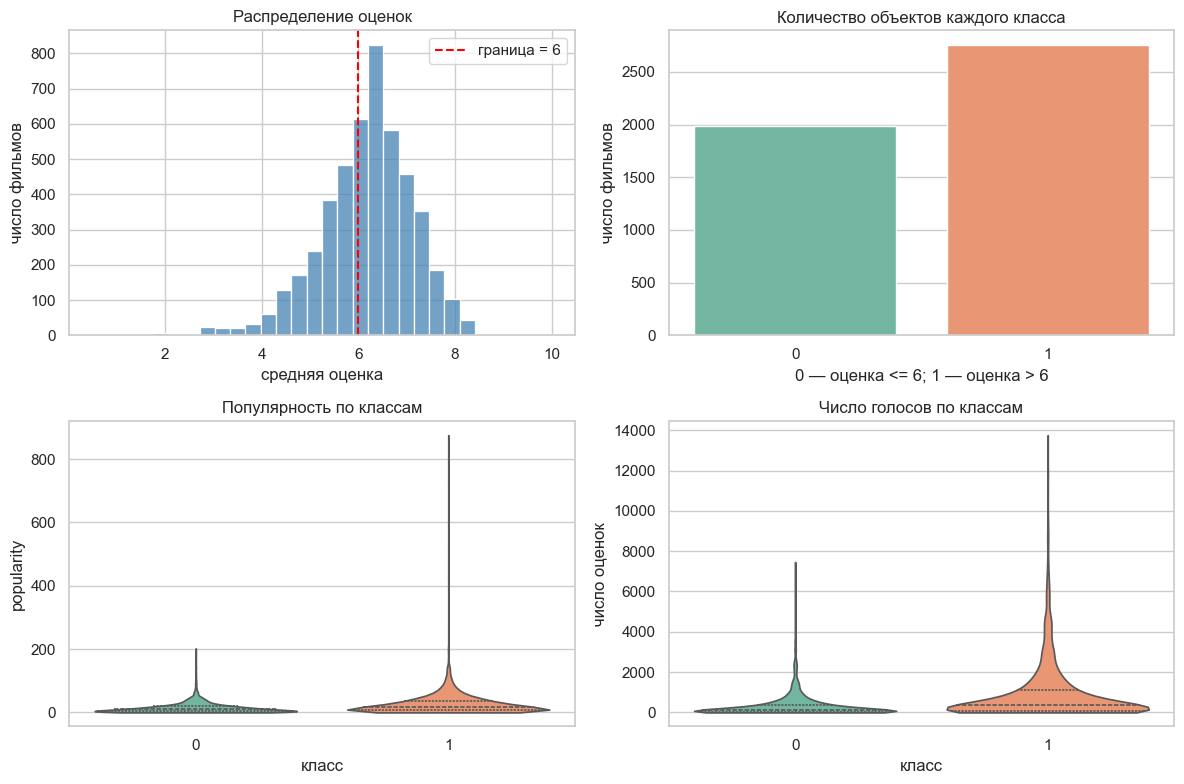

Доля хороших фильмов: 58.1%
Отношение большего класса к меньшему: 1.39


In [23]:
class_names = {0: "оценка <= 6", 1: "оценка > 6"}
class_counts = data["good_movie"].value_counts().sort_index()
class_shares = data["good_movie"].value_counts(normalize=True).sort_index()

display(pd.DataFrame({
    "количество": class_counts,
    "доля": class_shares,
}).rename(index=class_names).round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=data, x="vote_average", bins=30, ax=axes[0, 0], color="steelblue")
axes[0, 0].axvline(6, color="red", linestyle="--", label="граница = 6")
axes[0, 0].set_title("Распределение оценок")
axes[0, 0].set_xlabel("средняя оценка")
axes[0, 0].set_ylabel("число фильмов")
axes[0, 0].legend()

sns.countplot(data=data, x="good_movie", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Количество объектов каждого класса")
axes[0, 1].set_xlabel("0 — оценка <= 6; 1 — оценка > 6")
axes[0, 1].set_ylabel("число фильмов")

sns.violinplot(data=data, x="good_movie", y="popularity", ax=axes[1, 0], inner="quartile", palette="Set2", cut=0)
axes[1, 0].set_title("Популярность по классам")
axes[1, 0].set_xlabel("класс")
axes[1, 0].set_ylabel("popularity")

sns.violinplot(data=data, x="good_movie", y="vote_count", ax=axes[1, 1], inner="quartile", palette="Set2", cut=0)
axes[1, 1].set_title("Число голосов по классам")
axes[1, 1].set_xlabel("класс")
axes[1, 1].set_ylabel("число оценок")

plt.tight_layout()
plt.show()

print("Доля хороших фильмов:", f"{class_shares.loc[1]:.1%}")
print("Отношение большего класса к меньшему:", round(class_counts.max() / class_counts.min(), 2))

**Интерпретация.** При границе 6 положительный класс преобладает, но сильного дисбаланса нет: отношение размеров классов существенно меньше 2. По скрипичным диаграммам хорошие фильмы в среднем имеют больше голосов и несколько большую популярность, поэтому эти признаки могут быть полезны для классификации. Значения показаны без логарифмирования: отдельные очень популярные фильмы и фильмы с большим числом оценок вытягивают верхние хвосты распределений и сжимают их основную массу у нижней границы.

## 2. Множественная регрессия

Целевая переменная — числовая оценка `vote_average`. Используются два ранее изученных метода: **МНК** (`LinearRegression`) и **SVR**. Обе модели получают шесть признаков, поэтому регрессия является множественной.

Выборка делится на train/test в отношении 80/20. Разбиение одинаково для регрессии и последующей классификации. Пропуски заполняются медианами только по train; признаки стандартизируются внутри `Pipeline`.

In [24]:
X = data[features]
y_regression = data["vote_average"]
y_class = data["good_movie"]

train_index, test_index = train_test_split(
    data.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_class,
)

X_train, X_test = X.loc[train_index], X.loc[test_index]
y_reg_train = y_regression.loc[train_index]
y_reg_test = y_regression.loc[test_index]

regressors = {
    "МНК": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LinearRegression(),
    ),
    "SVR": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        SVR(kernel="rbf", C=2.0, epsilon=0.1),
    ),
}

reg_predictions = {}
reg_train_predictions = {}
for name, model in regressors.items():
    model.fit(X_train, y_reg_train)
    reg_predictions[name] = model.predict(X_test)
    reg_train_predictions[name] = model.predict(X_train)

display(pd.DataFrame({
    "реальная оценка": y_reg_test,
    **reg_predictions,
}, index=test_index).head(10).round(3))

,реальная оценка,МНК,SVR
2318,6.3,6.565,6.957
1810,6.9,6.635,6.581
4681,5.5,4.887,5.127
3522,4.2,5.479,5.501
4393,5.2,5.796,5.747
3618,6.4,6.587,6.635
3775,6.6,6.116,6.633
4641,7.5,6.535,6.310
2456,7.4,6.613,6.654
1114,6.6,6.176,5.921


## 3. Проверка адекватности регрессионных моделей

MAE и RMSE измеряются в пунктах рейтинга, MAPE — в процентах. Для MASE масштабом служит средняя абсолютная разность соседних оценок обучающих фильмов, упорядоченных по дате выхода. MASE меньше 1 означает преимущество над наивным прогнозом предыдущим наблюдением.

,MAE,RMSE,"MAPE, %",MASE
SVR,0.5754,0.7967,10.3729,0.5554
МНК,0.6330,0.8483,11.2512,0.6109


лучшая регрессионная модель по RMSE: SVR


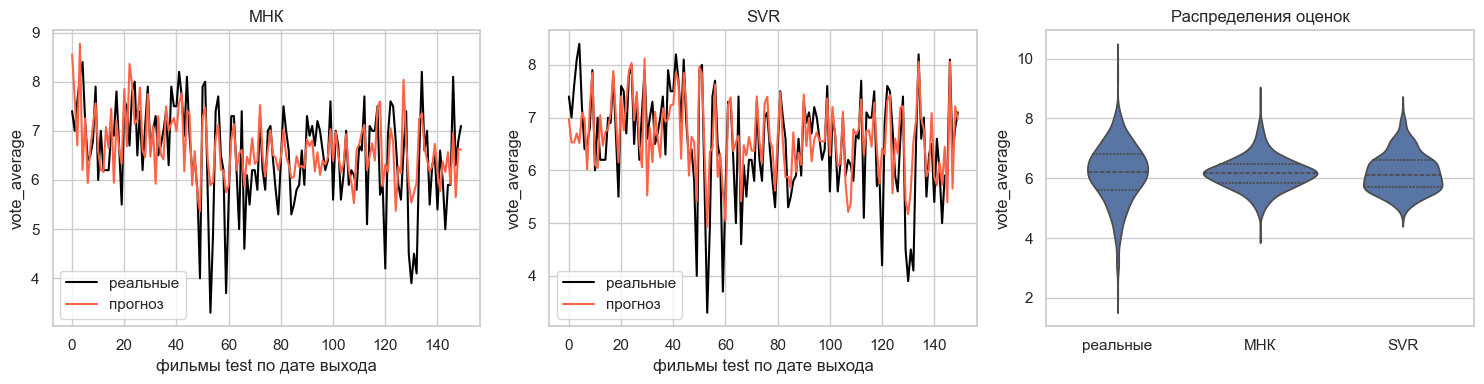

Лучшая модель SVR: MAE=0.575, RMSE=0.797, MAPE=10.37%, MASE=0.555.


In [25]:
ordered_train = data.loc[train_index].dropna(subset=["release_date"]).sort_values("release_date")
mase_scale = np.mean(np.abs(np.diff(ordered_train["vote_average"])))

def regression_scores(real, prediction):
    return {
        "MAE": mean_absolute_error(real, prediction),
        "RMSE": mean_squared_error(real, prediction) ** 0.5,
        "MAPE, %": np.mean(np.abs((real - prediction) / real)) * 100,
        "MASE": mean_absolute_error(real, prediction) / mase_scale,
    }

regression_table = pd.DataFrame({
    name: regression_scores(y_reg_test, prediction)
    for name, prediction in reg_predictions.items()
}).T.sort_values("RMSE")
display(regression_table.round(4))

best_regression = regression_table["RMSE"].idxmin()
print("лучшая регрессионная модель по RMSE:", best_regression)

ordered_test_index = data.loc[test_index].sort_values("release_date").index[:150]
positions = [list(test_index).index(i) for i in ordered_test_index]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes[:2], ["МНК", "SVR"]):
    ax.plot(range(len(positions)), y_regression.loc[ordered_test_index], label="реальные", color="black")
    ax.plot(range(len(positions)), reg_predictions[name][positions], label="прогноз", color="tomato")
    ax.set_title(name)
    ax.set_xlabel("фильмы test по дате выхода")
    ax.set_ylabel("vote_average")
    ax.legend()

violin = pd.DataFrame({
    "реальные": y_reg_test.to_numpy(),
    **reg_predictions,
}).melt(var_name="ряд", value_name="vote_average")
sns.violinplot(data=violin, x="ряд", y="vote_average", inner="quartile", ax=axes[2])
axes[2].set_title("Распределения оценок")
axes[2].set_xlabel("")
axes[2].set_ylabel("vote_average")
plt.tight_layout()
plt.show()

print(
    f"Лучшая модель {best_regression}: "
    f"MAE={regression_table.loc[best_regression, 'MAE']:.3f}, "
    f"RMSE={regression_table.loc[best_regression, 'RMSE']:.3f}, "
    f"MAPE={regression_table.loc[best_regression, 'MAPE, %']:.2f}%, "
    f"MASE={regression_table.loc[best_regression, 'MASE']:.3f}."
)

**Интерпретация регрессии.** Линейные графики показывают, что обе модели воспроизводят общий уровень оценок, но сглаживают крайние значения. На скрипичной диаграмме прогнозы заметно уже реального распределения: модели редко предсказывают очень низкие или очень высокие оценки. Лучшая модель выбирается по минимальному RMSE; остальные метрики подтверждают выбор. Значение MASE нужно сравнивать с 1: если оно меньше 1, регрессия лучше наивного прогноза.

## 4. Обучение моделей классификации

Выборка делится на train/test в отношении 80/20 со стратификацией. Обязательные методы — **kNN** и **SVM**. В качестве двух дополнительных методов используются **Logistic Regression** и дерево **CART**.

Пропуски заполняются медианами, рассчитанными только на train. Для kNN, SVM и Logistic Regression признаки также стандартизируются внутри `Pipeline`.

In [ ]:
y_train = y_class.loc[train_index]
y_test = y_class.loc[test_index]

def make_classifiers():
    scaled_steps = [SimpleImputer(strategy="median"), StandardScaler()]
    return {
        "kNN": make_pipeline(*scaled_steps, KNeighborsClassifier(n_neighbors=15, weights="distance")),
        "SVM": make_pipeline(*scaled_steps, SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
        "Logistic Regression": make_pipeline(
            *scaled_steps,
            LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        ),
        "CART": make_pipeline(
            SimpleImputer(strategy="median"),
            DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE),
        ),
    }

classifiers = make_classifiers()
print("train:", len(X_train), "test:", len(X_test))

train: 3792 test: 948
доли класса 1 — train/test: 0.581 / 0.581


## 5. Accuracy, F-мера, LogLoss и ROC-AUC

Чем выше Accuracy, F1 и ROC-AUC, тем лучше. Для LogLoss лучше меньшее значение, так как эта метрика штрафует уверенные неправильные вероятности.

По пункту 5 задания прогноз лучшей регрессии также переводится в класс: если спрогнозированная оценка выше 6, ответ равен 1. Для ROC и LogLoss расстояние прогноза от границы 6 переводится в вероятность сигмоидой; масштаб определяется по ошибкам регрессии на train.

,Accuracy,F1,LogLoss,ROC-AUC
kNN,0.7226,0.7598,0.5547,0.7872
Регрессия: SVR,0.7173,0.7541,0.5583,0.7877
Logistic Regression,0.6920,0.7474,0.5928,0.7457
SVM,0.7141,0.7451,0.5461,0.7875
CART,0.6962,0.7120,0.6182,0.7463


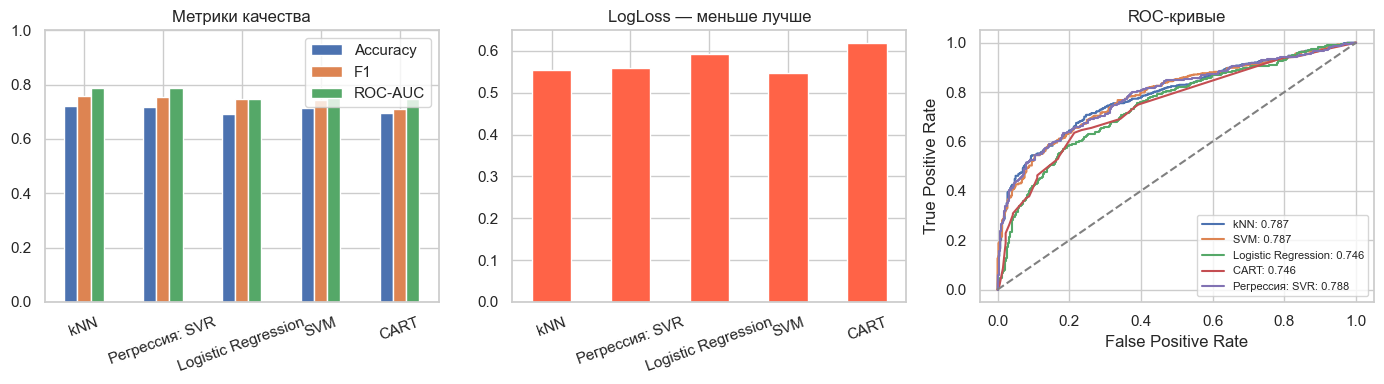

Максимальный F1 у kNN: 0.760; Accuracy=0.723.
Максимальный ROC-AUC у Регрессия: SVR: 0.788; минимальный LogLoss у SVM: 0.546.


In [27]:
def classification_scores(real, labels, probabilities):
    probabilities = np.clip(probabilities, 1e-7, 1 - 1e-7)
    return {
        "Accuracy": accuracy_score(real, labels),
        "F1": f1_score(real, labels),
        "LogLoss": log_loss(real, probabilities, labels=[0, 1]),
        "ROC-AUC": roc_auc_score(real, probabilities),
    }

predictions = {}
probabilities = {}

for name, model in classifiers.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

regression_classifier_name = f"Регрессия: {best_regression}"
best_reg_prediction = reg_predictions[best_regression]
regression_scale = np.std(y_reg_train - reg_train_predictions[best_regression])
predictions[regression_classifier_name] = (best_reg_prediction > 6).astype(int)
probabilities[regression_classifier_name] = 1 / (
    1 + np.exp(-(best_reg_prediction - 6) / regression_scale)
)

score_table = pd.DataFrame({
    name: classification_scores(y_test, predictions[name], probabilities[name])
    for name in predictions
}).T.sort_values(["F1", "ROC-AUC"], ascending=False)

display(score_table.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
score_table[["Accuracy", "F1", "ROC-AUC"]].plot(kind="bar", ylim=(0, 1), ax=axes[0])
axes[0].set_title("Метрики качества")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
score_table["LogLoss"].plot(kind="bar", color="tomato", ax=axes[1])
axes[1].set_title("LogLoss — меньше лучше")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

for name, probability in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probability)
    axes[2].plot(fpr, tpr, label=f"{name}: {roc_auc_score(y_test, probability):.3f}")
axes[2].plot([0, 1], [0, 1], "--", color="gray")
axes[2].set_title("ROC-кривые")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

best_f1_now = score_table["F1"].idxmax()
best_auc_now = score_table["ROC-AUC"].idxmax()
best_loss_now = score_table["LogLoss"].idxmin()
print(
    f"Максимальный F1 у {best_f1_now}: {score_table.loc[best_f1_now, 'F1']:.3f}; "
    f"Accuracy={score_table.loc[best_f1_now, 'Accuracy']:.3f}."
)
print(
    f"Максимальный ROC-AUC у {best_auc_now}: {score_table.loc[best_auc_now, 'ROC-AUC']:.3f}; "
    f"минимальный LogLoss у {best_loss_now}: {score_table.loc[best_loss_now, 'LogLoss']:.3f}."
)

**Интерпретация метрик и ROC.** Столбцы показывают качество готового решения при пороге 0.5, а ROC-кривые — качество ранжирования при всех возможных порогах. Поэтому лидер по F1 может отличаться от лидера по ROC-AUC и LogLoss. Серая диагональ соответствует случайному классификатору; чем выше кривая над ней, тем полезнее модель.

## 6. Матрицы ошибок

В каждой матрице строки — реальные классы, столбцы — прогноз. Главная диагональ содержит правильные ответы. Нижняя левая ячейка — хорошие фильмы, ошибочно отнесённые к плохим; верхняя правая — фильмы с оценкой не выше 6, ошибочно названные хорошими.

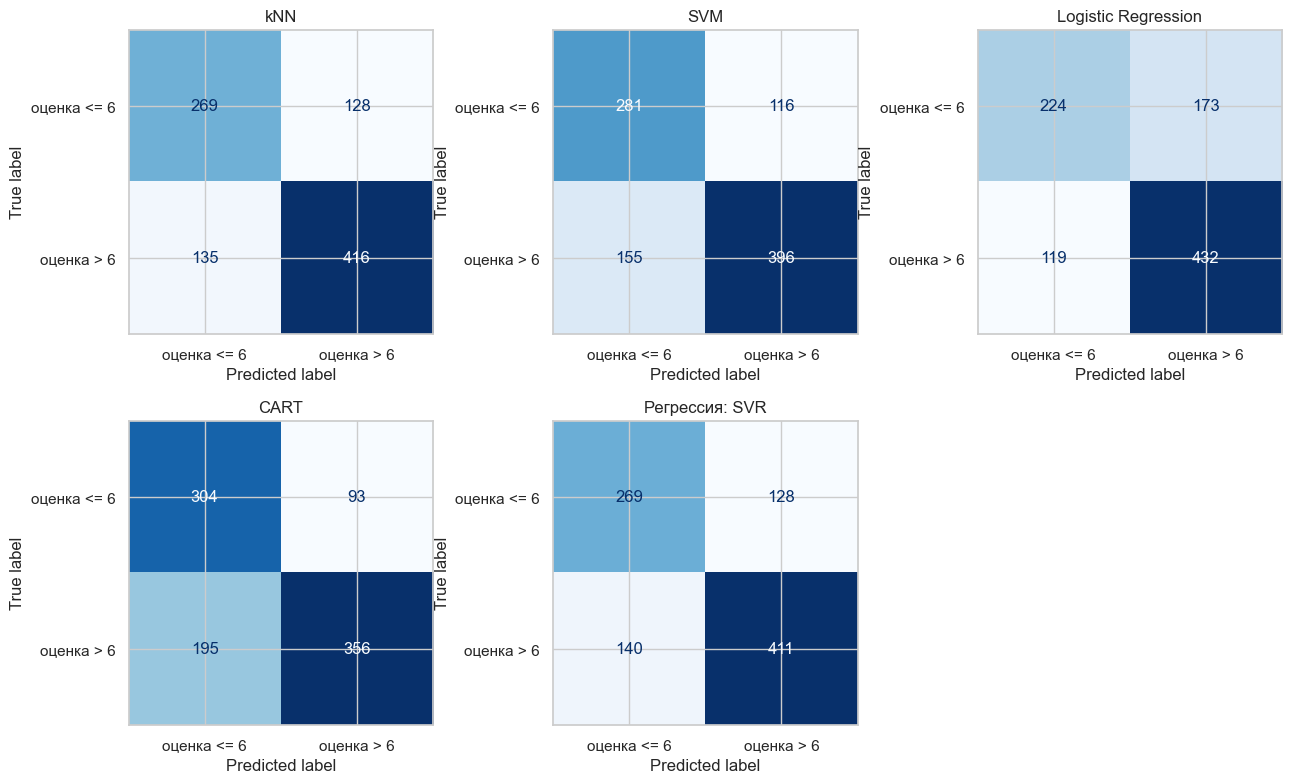

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (name, labels) in zip(axes.ravel(), predictions.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, labels),
        display_labels=["оценка <= 6", "оценка > 6"],
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
for ax in axes.ravel()[len(predictions):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Интерпретация матриц.** По диагонали находятся правильные ответы. Модель с большим правым нижним числом лучше находит хорошие фильмы; модель с большим левым верхним числом лучше распознаёт фильмы с оценкой не выше 6. Вне диагонали видно компромисс: увеличение полноты хороших фильмов обычно повышает и число ложных срабатываний.

## 7. Какие признаки использовали модели

Для интерпретации показываю коэффициенты Logistic Regression и важности CART. Положительный коэффициент логистической регрессии увеличивает вероятность класса «хороший фильм», отрицательный — уменьшает. У CART важности не имеют знака и показывают относительный вклад признака в разбиения дерева.

,коэффициент Logistic Regression,важность CART
признак,,
runtime,0.7690,0.3844
log_vote_count,0.8393,0.2748
log_budget,-0.4462,0.2062
release_year,-0.3660,0.0674
log_popularity,-0.1583,0.0640
log_revenue,-0.0736,0.0031


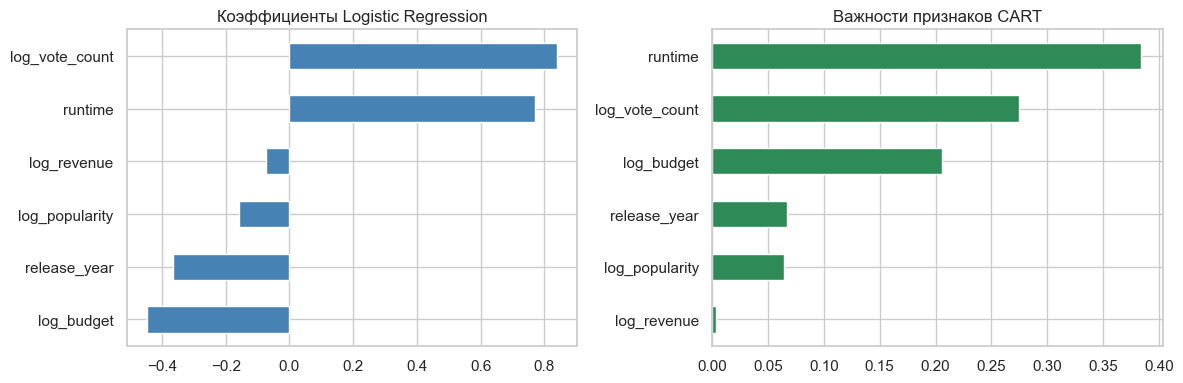

In [29]:
logistic = classifiers["Logistic Regression"].named_steps["logisticregression"]
cart = classifiers["CART"].named_steps["decisiontreeclassifier"]

importance = pd.DataFrame({
    "признак": features,
    "коэффициент Logistic Regression": logistic.coef_[0],
    "важность CART": cart.feature_importances_,
}).set_index("признак")
display(importance.sort_values("важность CART", ascending=False).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
importance["коэффициент Logistic Regression"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Коэффициенты Logistic Regression")
axes[0].set_ylabel("")
importance["важность CART"].sort_values().plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Важности признаков CART")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

**Интерпретация признаков.** В Logistic Regression рост числа голосов и длительности сильнее всего связан с вероятностью оценки выше 6. После учёта остальных признаков бюджет и более поздний год выхода имеют отрицательные коэффициенты. CART чаще всего разбивает данные по длительности, числу голосов и бюджету. Эти зависимости описывают датасет, но не доказывают причинность: большой бюджет сам по себе не делает оценку ниже.

## 8. Изменение границы и балансировка классов

При исходной границе 6 классы имеют доли около 42/58. Чтобы сделать их практически равными, граница повышается до медианной оценки **6.2**. Теперь класс 1 означает `vote_average > 6.2`. Модели обучаются повторно на тех же объектах train и проверяются на тех же объектах test.

,граница 6,граница 6.2
класс 0,1984,2385
класс 1,2756,2355


,Accuracy,F1,LogLoss,ROC-AUC
kNN,0.7110,0.6879,0.6232,0.7705
Регрессия: SVR,0.7036,0.6867,0.5703,0.7761
SVM,0.6973,0.6651,0.5644,0.7713
Logistic Regression,0.6772,0.6623,0.6122,0.7339
CART,0.6772,0.6357,0.6040,0.7324


,"Accuracy, граница 6","Accuracy, граница 6.2","F1, граница 6","F1, граница 6.2"
CART,0.6962,0.6772,0.7120,0.6357
Logistic Regression,0.6920,0.6772,0.7474,0.6623
SVM,0.7141,0.6973,0.7451,0.6651
kNN,0.7226,0.7110,0.7598,0.6879
Регрессия: SVR,0.7173,0.7036,0.7541,0.6867


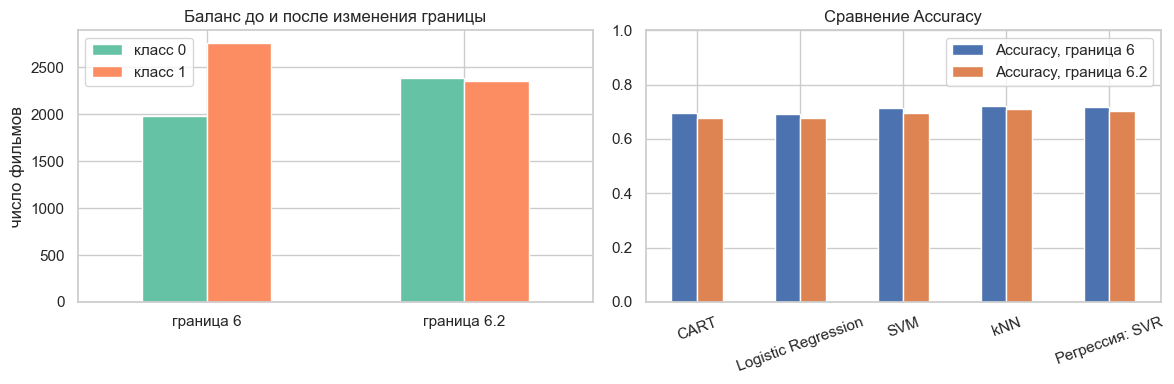

После границы 6.2 лучший F1 у kNN: F1=0.688, Accuracy=0.711.


In [30]:
BALANCED_BORDER = 6.2
y_balanced = (data["vote_average"] > BALANCED_BORDER).astype(int)
y_balanced_train = y_balanced.loc[train_index]
y_balanced_test = y_balanced.loc[test_index]

balance_comparison = pd.DataFrame({
    "граница 6": y_class.value_counts().sort_index(),
    "граница 6.2": y_balanced.value_counts().sort_index(),
})
balance_comparison.index = ["класс 0", "класс 1"]
display(balance_comparison)

balanced_models = make_classifiers()
balanced_predictions = {}
balanced_probabilities = {}
for name, model in balanced_models.items():
    model.fit(X_train, y_balanced_train)
    balanced_predictions[name] = model.predict(X_test)
    balanced_probabilities[name] = model.predict_proba(X_test)[:, 1]

balanced_predictions[regression_classifier_name] = (best_reg_prediction > BALANCED_BORDER).astype(int)
balanced_probabilities[regression_classifier_name] = 1 / (
    1 + np.exp(-(best_reg_prediction - BALANCED_BORDER) / regression_scale)
)

balanced_scores = pd.DataFrame({
    name: classification_scores(
        y_balanced_test,
        balanced_predictions[name],
        balanced_probabilities[name],
    )
    for name in balanced_predictions
}).T.sort_values(["F1", "ROC-AUC"], ascending=False)
display(balanced_scores.round(4))

comparison = pd.DataFrame({
    "Accuracy, граница 6": score_table["Accuracy"],
    "Accuracy, граница 6.2": balanced_scores["Accuracy"],
    "F1, граница 6": score_table["F1"],
    "F1, граница 6.2": balanced_scores["F1"],
})
display(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
balance_comparison.T.plot(kind="bar", ax=axes[0], color=["#66c2a5", "#fc8d62"])
axes[0].set_title("Баланс до и после изменения границы")
axes[0].set_xlabel("")
axes[0].set_ylabel("число фильмов")
axes[0].tick_params(axis="x", rotation=0)

comparison[["Accuracy, граница 6", "Accuracy, граница 6.2"]].plot(
    kind="bar", ylim=(0, 1), ax=axes[1]
)
axes[1].set_title("Сравнение Accuracy")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

best_balanced_now = balanced_scores["F1"].idxmax()
print(
    f"После границы 6.2 лучший F1 у {best_balanced_now}: "
    f"F1={balanced_scores.loc[best_balanced_now, 'F1']:.3f}, "
    f"Accuracy={balanced_scores.loc[best_balanced_now, 'Accuracy']:.3f}."
)

**Интерпретация балансировки.** Перенос границы с 6 до 6.2 почти точно выровнял классы: 2385 против 2355. Изменение метрик нужно связывать не только с балансом, но и с новым смыслом класса: теперь модели различают фильмы около самой плотной части распределения оценок, что является более трудной задачей. Правый график напрямую показывает, какая модель выиграла или потеряла в Accuracy.